#Step 1: Install Libraries in Google Colab

In [ ]:
!pip install tensorflow streamlit pyngrok shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 44.5 MB/s eta 0:00:00




#Step 2: Upload Dataset



In [4]:
from google.colab import files
uploaded = files.upload()

Saving medical_xai_dataset.csv to medical_xai_dataset.csv


#Step 3: Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

#Step 4: Load Dataset

In [5]:
df = pd.read_csv("medical_xai_dataset.csv")

print(df.head())
print(df.shape)

   Age   BMI  Glucose  BloodPressure  Insulin  HeartRate  Cholesterol  \
0   69  31.7      180            117       90        106          214   
1   32  24.5      130             69      279         84          237   
2   78  20.3      117            113      298         61          263   
3   38  28.0       73             64      220         69          127   
4   41  22.8      104             95      237         89          251   

   DiseaseRisk  
0            0  
1            0  
2            0  
3            0  
4            0  
(120, 8)


#Step 5: Features and Target

In [ ]:
X = df.drop("DiseaseRisk", axis=1)
y = df["DiseaseRisk"]

#Step 6: Normalize Data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Step 7: Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

#Step 8: ANN Model
Deep Learning with Regularization

In [ ]:
ann_model = Sequential()

ann_model.add(Dense(
    128,
    activation='relu',
    input_shape=(X_train.shape[1],),
    kernel_regularizer=l2(0.001)
))

ann_model.add(BatchNormalization())

ann_model.add(Dropout(0.4))

ann_model.add(Dense(
    64,
    activation='relu',
    kernel_regularizer=l2(0.001)
))

ann_model.add(BatchNormalization())

ann_model.add(Dropout(0.3))

ann_model.add(Dense(32, activation='relu'))

ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 384 (1.50 KB)

#Step 9: Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#Step 10: Train ANN

In [ ]:
history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.5658 - loss: 1.0349 - val_accuracy: 0.5500 - val_loss: 0.7976
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4737 - loss: 1.0754 - val_accuracy: 0.5500 - val_loss: 0.7995
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4868 - loss: 1.0078 - val_accuracy: 0.5000 - val_loss: 0.8008
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5132 - loss: 0.9986 - val_accuracy: 0.4500 - val_loss: 0.8009
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6447 - loss: 0.7723 - val_accuracy: 0.6500 - val_loss: 0.8006
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5263 - loss: 0.8322 - val_accuracy: 0.5500 - val_loss: 0.7990
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5789 - loss: 0.8970 - val_accuracy: 0.5000 - val_loss: 0.7965
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6842 - loss: 0.6917 - val_accuracy: 0.4500 - val_loss:

#Step 11: Evaluate ANN

In [ ]:
pred = ann_model.predict(X_test)
pred = (pred > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))

print(confusion_matrix(y_test, pred))

print(classification_report(y_test, pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Accuracy: 0.5
[[4 9]
 [3 8]]
              precision    recall  f1-score   support

           0       0.57      0.31      0.40        13
           1       0.47      0.73      0.57        11

    accuracy                           0.50        24
   macro avg       0.52      0.52      0.49        24
weighted avg       0.53      0.50      0.48        24



#Step 12: Accuracy Graph

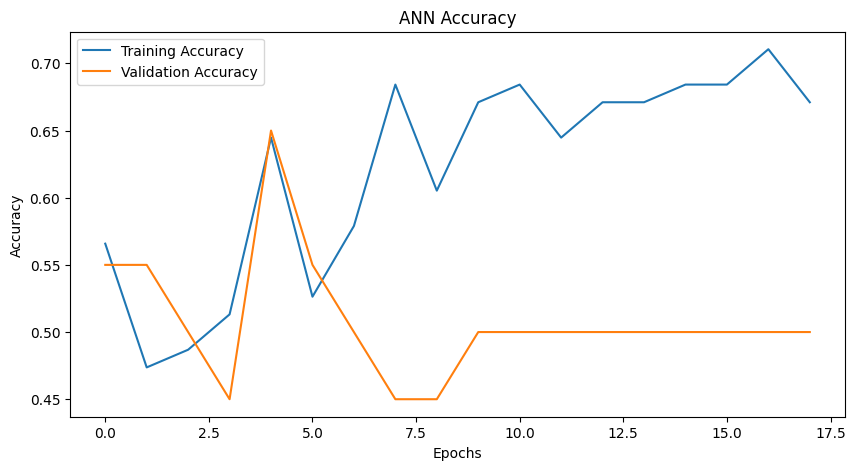

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ANN Accuracy")

plt.legend()

plt.show()

#Step 13: Loss Graph

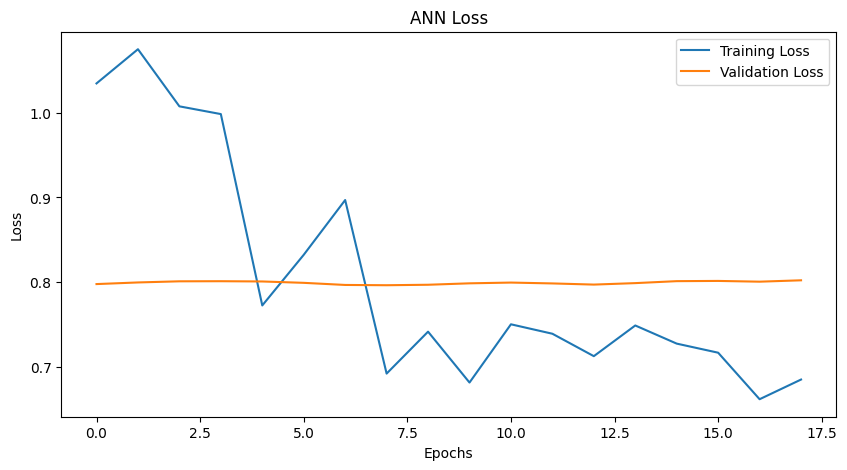

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN Loss")

plt.legend()

plt.show()

#Step 14: CNN Model for Tabular Data
Reshape Data for CNN

In [ ]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

#Step 15: Build CNN

In [ ]:
cnn_model = Sequential()

cnn_model.add(
    Conv1D(
        filters=64,
        kernel_size=2,
        activation='relu',
        input_shape=(X_train_cnn.shape[1],1)
    )
)

cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Dropout(0.3))

cnn_model.add(Flatten())

cnn_model.add(Dense(
    64,
    activation='relu',
    kernel_regularizer=l2(0.001)
))

cnn_model.add(Dropout(0.3))

cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,609 (49.25 KB)

 Trainable params: 12,609 (49.25 KB)

 Non-trainable params: 0 (0.00 B)

#Step 16: Train CNN

In [ ]:
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.5789 - loss: 0.7848 - val_accuracy: 0.5500 - val_loss: 0.7998
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5658 - loss: 0.7869 - val_accuracy: 0.6000 - val_loss: 0.7932
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6053 - loss: 0.7513 - val_accuracy: 0.4500 - val_loss: 0.7942
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5921 - loss: 0.7625 - val_accuracy: 0.4500 - val_loss: 0.7944
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6053 - loss: 0.7764 - val_accuracy: 0.5500 - val_loss: 0.7945
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5921 - loss: 0.7577 - val_accuracy: 0.5000 - val_loss: 0.7939
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5395 - loss: 0.7601 - val_accuracy: 0.4500 - val_loss: 0.7934
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6316 - loss: 0.7529 - val_accuracy: 0.4500 - val_loss

#Step 17: Evaluate CNN

In [ ]:
cnn_pred = cnn_model.predict(X_test_cnn)
cnn_pred = (cnn_pred > 0.5).astype(int)

print("CNN Accuracy:", accuracy_score(y_test, cnn_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
CNN Accuracy: 0.4166666666666667


#Step 18: Confusion Matrix Heatmap

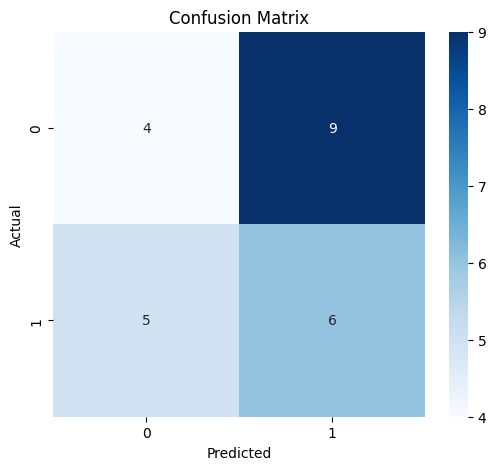

In [ ]:
cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#Step 19: Explainable AI using SHAP

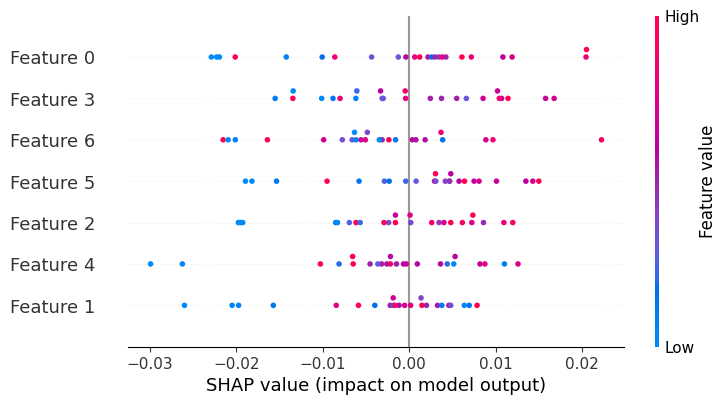

In [ ]:
import shap

explainer = shap.Explainer(ann_model, X_train)

shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

#Step 20: Save Model

In [ ]:
ann_model.save("medical_ann_model.h5")
cnn_model.save("medical_cnn_model.h5")

#WEB APP

In [7]:

!pip install gradio tensorflow pandas numpy scikit-learn


import pandas as pd
import numpy as np
import tensorflow as tf
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


df = pd.read_csv("medical_xai_dataset.csv")


X = df.drop("DiseaseRisk", axis=1)
y = df["DiseaseRisk"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


model.fit(
    X_train,
    y_train,
    epochs=10
)


def predict_risk(age, bmi, glucose):

    data = np.array([[age, bmi, glucose]])

    data = scaler.transform(data)

    prediction = model.predict(data)

    if prediction[0][0] > 0.5:
        return "High Disease Risk"
    else:
        return "Low Disease Risk"


app = gr.Interface(
    fn=predict_risk,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="BMI"),
        gr.Number(label="Glucose")
    ],
    outputs="text",
    title="Disease Risk Prediction System",
    description="Deep Learning Medical Prediction Web App"
)


app.launch(share=True)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5417 - loss: 0.7023
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5938 - loss: 0.6926
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6042 - loss: 0.6853
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6042 - loss: 0.6792
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6354 - loss: 0.6738
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6354 - loss: 0.6696
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6458 - loss: 0.6643
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6667 - loss: 0.6599
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6667 - loss: 0.6562
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6667 - loss: 0.6523
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc714be9cfec588d19.gradio.live

This share link expires in 1 